## Problem Statement

### Context

AllLife Bank is a US bank that has a growing customer base. The majority of these customers are liability customers (depositors) with varying sizes of deposits. The number of customers who are also borrowers (asset customers) is quite small, and the bank is interested in expanding this base rapidly to bring in more loan business and in the process, earn more through the interest on loans. In particular, the management wants to explore ways of converting its liability customers to personal loan customers (while retaining them as depositors).

A campaign that the bank ran last year for liability customers showed a healthy conversion rate of over 9% success. This has encouraged the retail marketing department to devise campaigns with better target marketing to increase the success ratio.

You as a Data scientist at AllLife bank have to build a model that will help the marketing department to identify the potential customers who have a higher probability of purchasing the loan.

### Objective

To predict whether a liability customer will buy personal loans, to understand which customer attributes are most significant in driving purchases, and identify which segment of customers to target more.

### Data Dictionary
* `ID`: Customer ID
* `Age`: Customer’s age in completed years
* `Experience`: #years of professional experience
* `Income`: Annual income of the customer (in thousand dollars)
* `ZIP Code`: Home Address ZIP code.
* `Family`: the Family size of the customer
* `CCAvg`: Average spending on credit cards per month (in thousand dollars)
* `Education`: Education Level. 1: Undergrad; 2: Graduate;3: Advanced/Professional
* `Mortgage`: Value of house mortgage if any. (in thousand dollars)
* `Personal_Loan`: Did this customer accept the personal loan offered in the last campaign? (0: No, 1: Yes)
* `Securities_Account`: Does the customer have securities account with the bank? (0: No, 1: Yes)
* `CD_Account`: Does the customer have a certificate of deposit (CD) account with the bank? (0: No, 1: Yes)
* `Online`: Do customers use internet banking facilities? (0: No, 1: Yes)
* `CreditCard`: Does the customer use a credit card issued by any other Bank (excluding All life Bank)? (0: No, 1: Yes)

## Importing necessary libraries

In [ ]:
# Installing the libraries with the specified version.
!pip install numpy pandas matplotlib seaborn scikit-learn sklearn-pandas -q --user
!pip install uszipcode
!pip install sqlalchemy-mate==2.0.0

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.0/57.0 kB 5.5 MB/s eta 0:00:00
  Created wheel for atomicwrites: filename=atomicwrites-1.4.1-py2.py3-none-any.whl size=6943 sha256=b0479f4569c08d3cd1ba46d0be4b37e3da70867a2038767ed5db95609aece2f9
  Stored in directory: /root/.cache/pip/wheels/f7/99/9c/d24e98c35f30eba0c367ad1e7888d396d676abb35fe1e7611c
Successfully built atomicwrites
  Attempting uninstall: sqlalchemy-mate
    Found existing installation: sqlalchemy_mate 2.0.0.3
    Uninstalling sqlalchemy_mate-2.0.0.3:
      Successfully uninstalled sqlalchemy_mate-2.0.0.3


**Note**:

1. After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab), write the relevant code for the project from the next cell, and run all cells sequentially from the next cell.

2. On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn import tree

from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score
from sklearn.metrics import accuracy_score

## Loading the dataset

In [ ]:
df = pd.read_csv('Loan_Modelling.csv')
data = df.copy()
data

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,29,3,40,92697,1,1.9,3,0,0,0,0,1,0
4996,4997,30,4,15,92037,4,0.4,1,85,0,0,0,1,0
4997,4998,63,39,24,93023,2,0.3,3,0,0,0,0,0,0
4998,4999,65,40,49,90034,3,0.5,2,0,0,0,0,1,0


## Data Overview

* Observations
* Sanity checks

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              5000 non-null   int64  
 4   ZIPCode             5000 non-null   int64  
 5   Family              5000 non-null   int64  
 6   CCAvg               5000 non-null   float64
 7   Education           5000 non-null   int64  
 8   Mortgage            5000 non-null   int64  
 9   Personal_Loan       5000 non-null   int64  
 10  Securities_Account  5000 non-null   int64  
 11  CD_Account          5000 non-null   int64  
 12  Online              5000 non-null   int64  
 13  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


In [ ]:
data.describe()

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
mean,2500.500000,45.338400,20.104600,73.774200,93169.257000,2.396400,1.937938,1.881000,56.498800,0.096000,0.104400,0.06040,0.596800,0.294000
std,1443.520003,11.463166,11.467954,46.033729,1759.455086,1.147663,1.747659,0.839869,101.713802,0.294621,0.305809,0.23825,0.490589,0.455637
min,1.000000,23.000000,-3.000000,8.000000,90005.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,1250.750000,35.000000,10.000000,39.000000,91911.000000,1.000000,0.700000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
50%,2500.500000,45.000000,20.000000,64.000000,93437.000000,2.000000,1.500000,2.000000,0.000000,0.000000,0.000000,0.00000,1.000000,0.000000
75%,3750.250000,55.000000,30.000000,98.000000,94608.000000,3.000000,2.500000,3.000000,101.000000,0.000000,0.000000,0.00000,1.000000,1.000000
max,5000.000000,67.000000,43.000000,224.000000,96651.000000,4.000000,10.000000,3.000000,635.000000,1.000000,1.000000,1.00000,1.000000,1.000000


#### Observations:
* Very uniform data as the median and mean are almost equal for all columns except mortgage.
* Very little skewness is present

## Exploratory Data Analysis.

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

**Questions**:

1. What is the distribution of mortgage attribute? Are there any noticeable patterns or outliers in the distribution?
2. How many customers have credit cards?
3. What are the attributes that have a strong correlation with the target attribute (personal loan)?
4. How does a customer's interest in purchasing a loan vary with their age?
5. How does a customer's interest in purchasing a loan vary with their education?

#### Univariate analysis

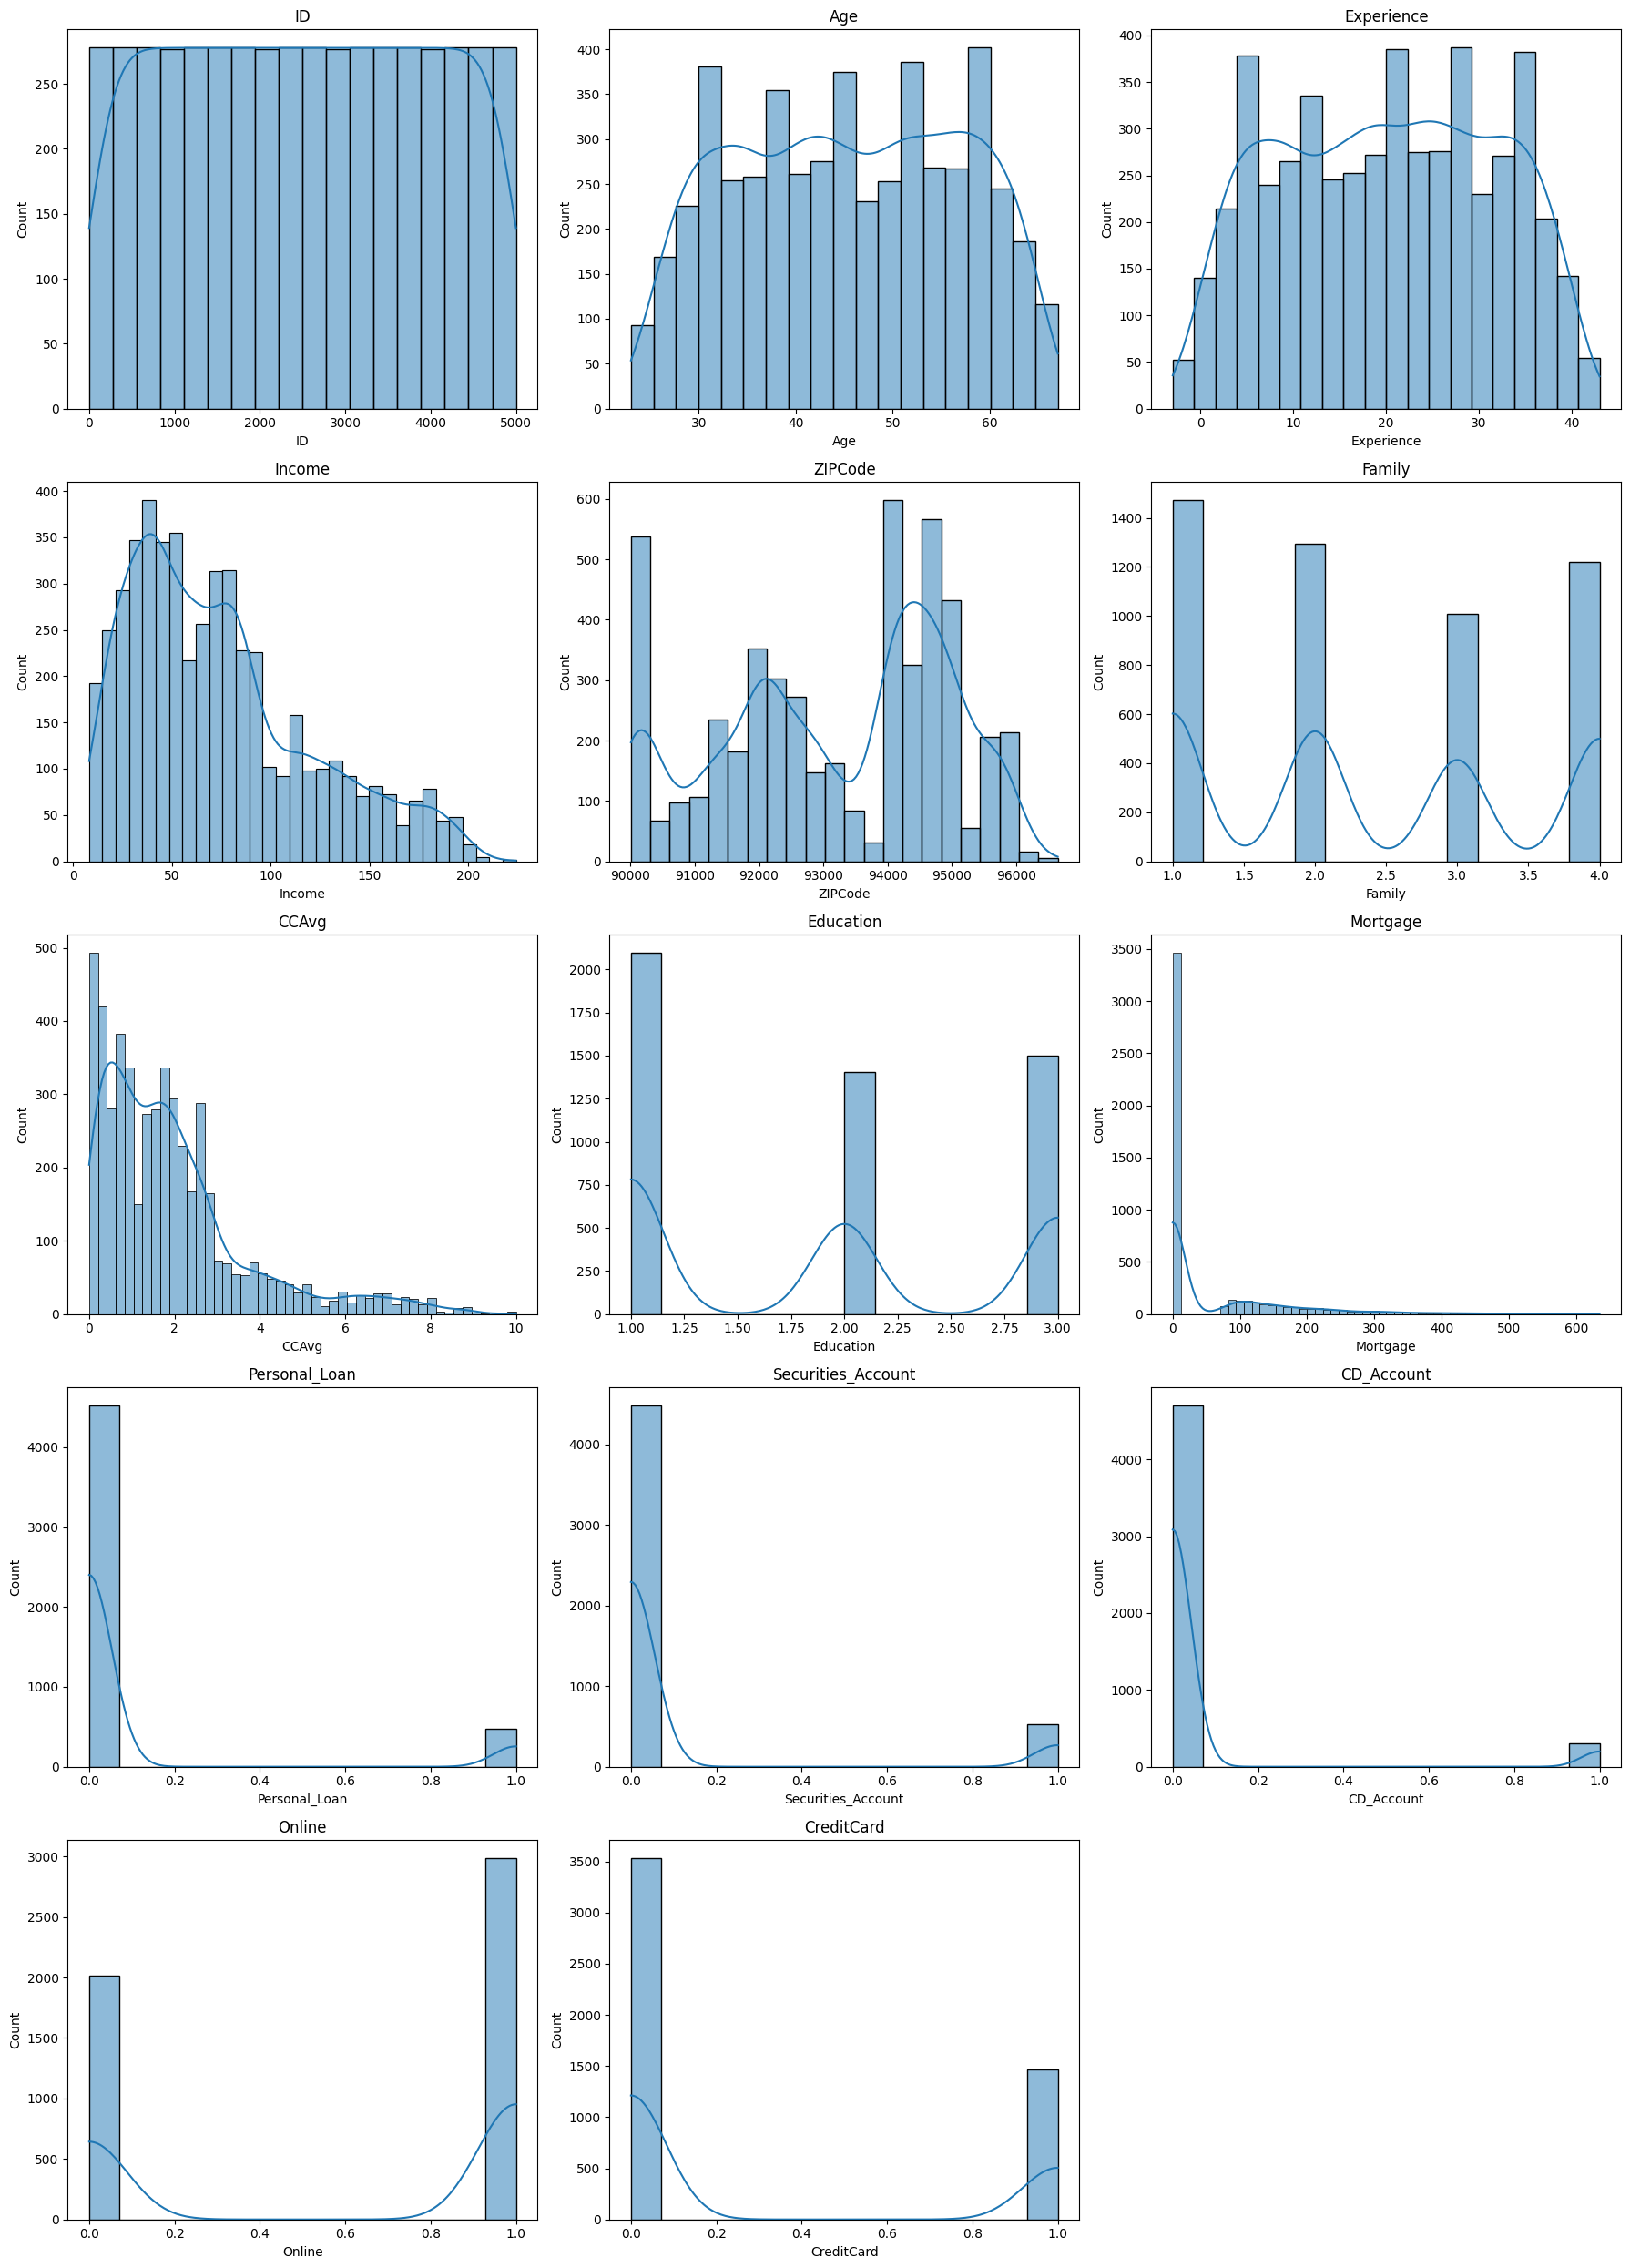

In [ ]:
fig, axes = plt.subplots(5, 3, figsize=(18, 25))
axes = axes.flatten()

for i, col in enumerate(data.columns[:15]):
    sns.histplot(data[col], kde=True, ax=axes[i])
    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

#### Bivariate analysis

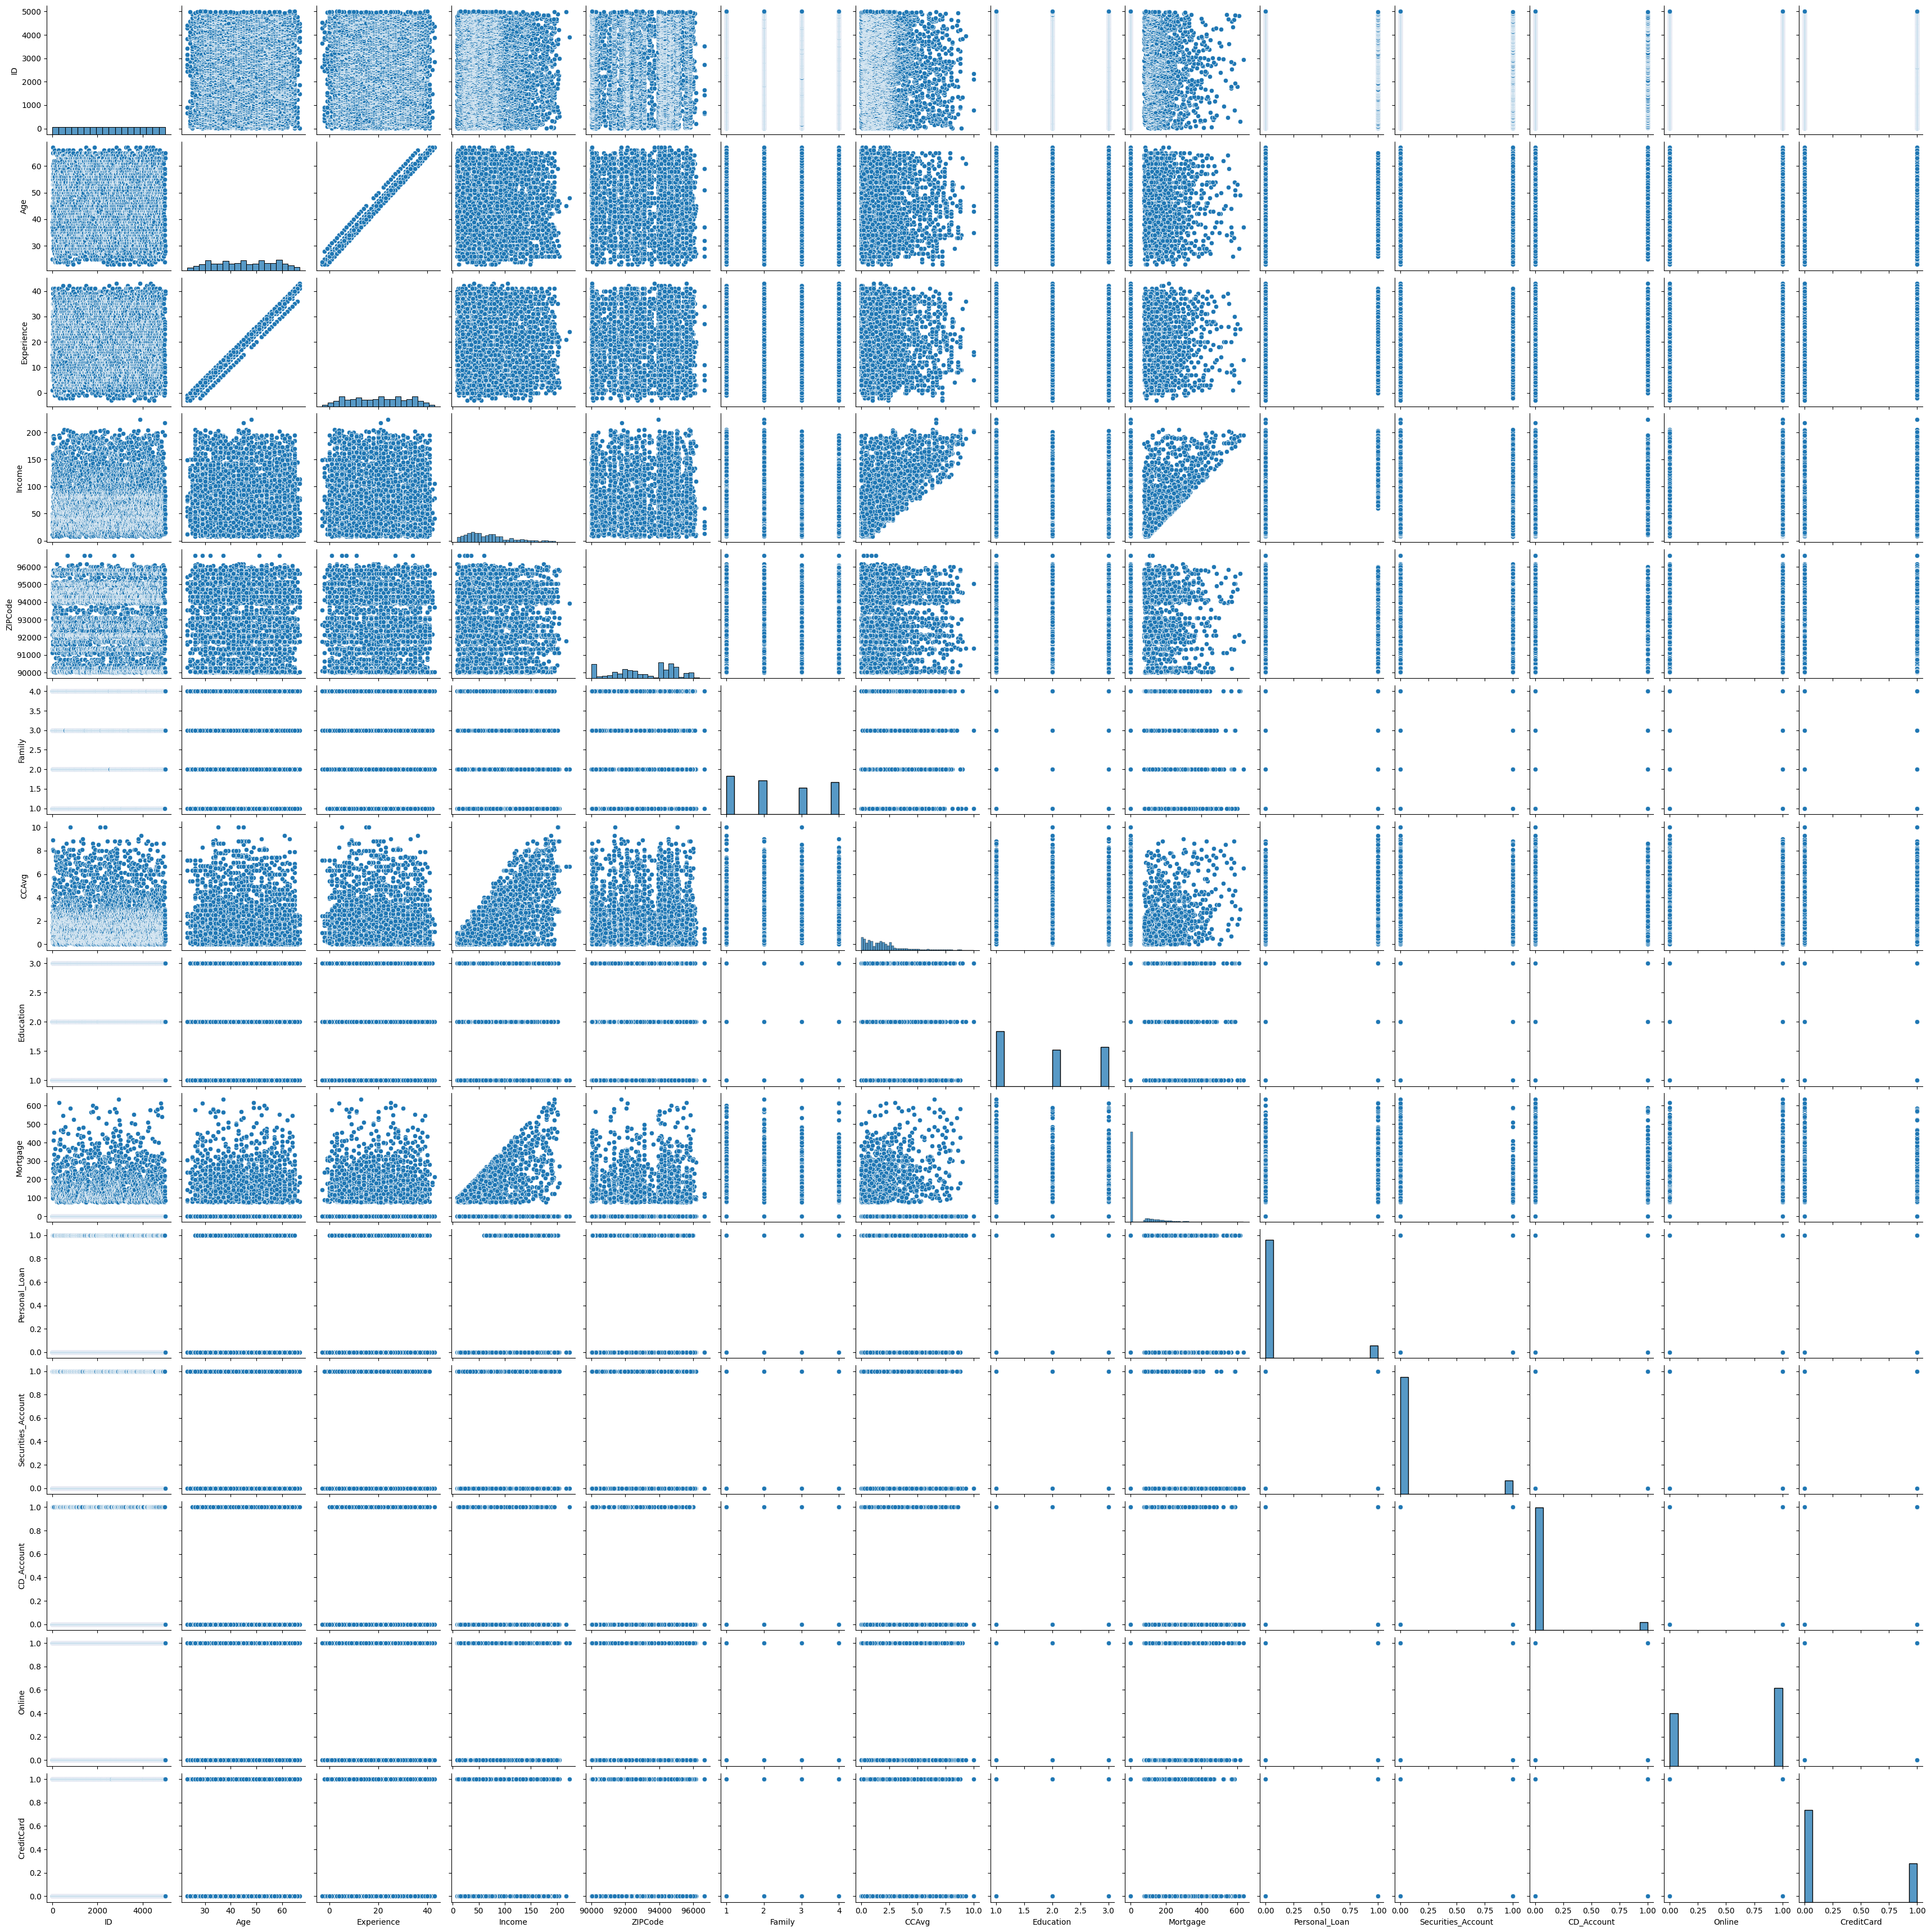

In [ ]:
sns.pairplot(data)
plt.show()

##### Observation:
* We can see that age and experience are almost perfectly strongly correlated.

#### Other plots

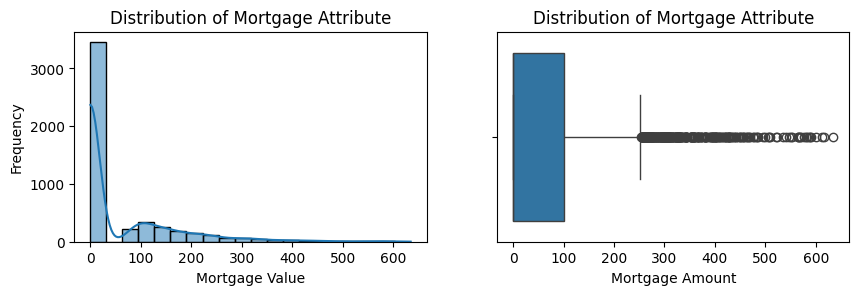

In [ ]:
plt.figure(figsize=(10, 6))
plt.subplot(2, 2, 1)
sns.histplot(data['Mortgage'], bins=20, kde=True)
plt.title('Distribution of Mortgage Attribute')
plt.xlabel('Mortgage Value')
plt.ylabel('Frequency')

plt.subplot(2, 2, 2)
sns.boxplot(x='Mortgage', data=data)
plt.title('Distribution of Mortgage Attribute')
plt.xlabel('Mortgage Amount')
plt.show()

### Observations:
*   There are many outliers for the mortgage attribute from the boxplot
*   The data is highly positively skewed
*   This can indicate that have a huge financial burden on mortgage take up loans to pay off their mortgage.



In [ ]:
print(len(data[data['CreditCard'] == 1]))
print(len(data[data['CreditCard'] == 0]))

1470
3530


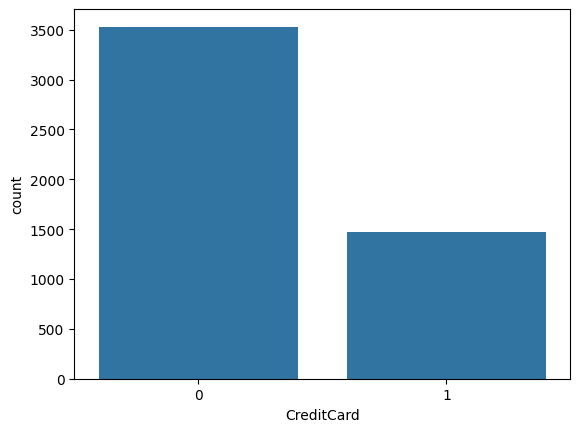

In [ ]:
sns.countplot(x='CreditCard', data=data)
plt.show()

### Observations:
*   There are 3530 customers having no credit card
*   There are 1470 customers having a credit card
*   Those who are having a credit card can be potential customers as they can opt for another loan or credit card plan.



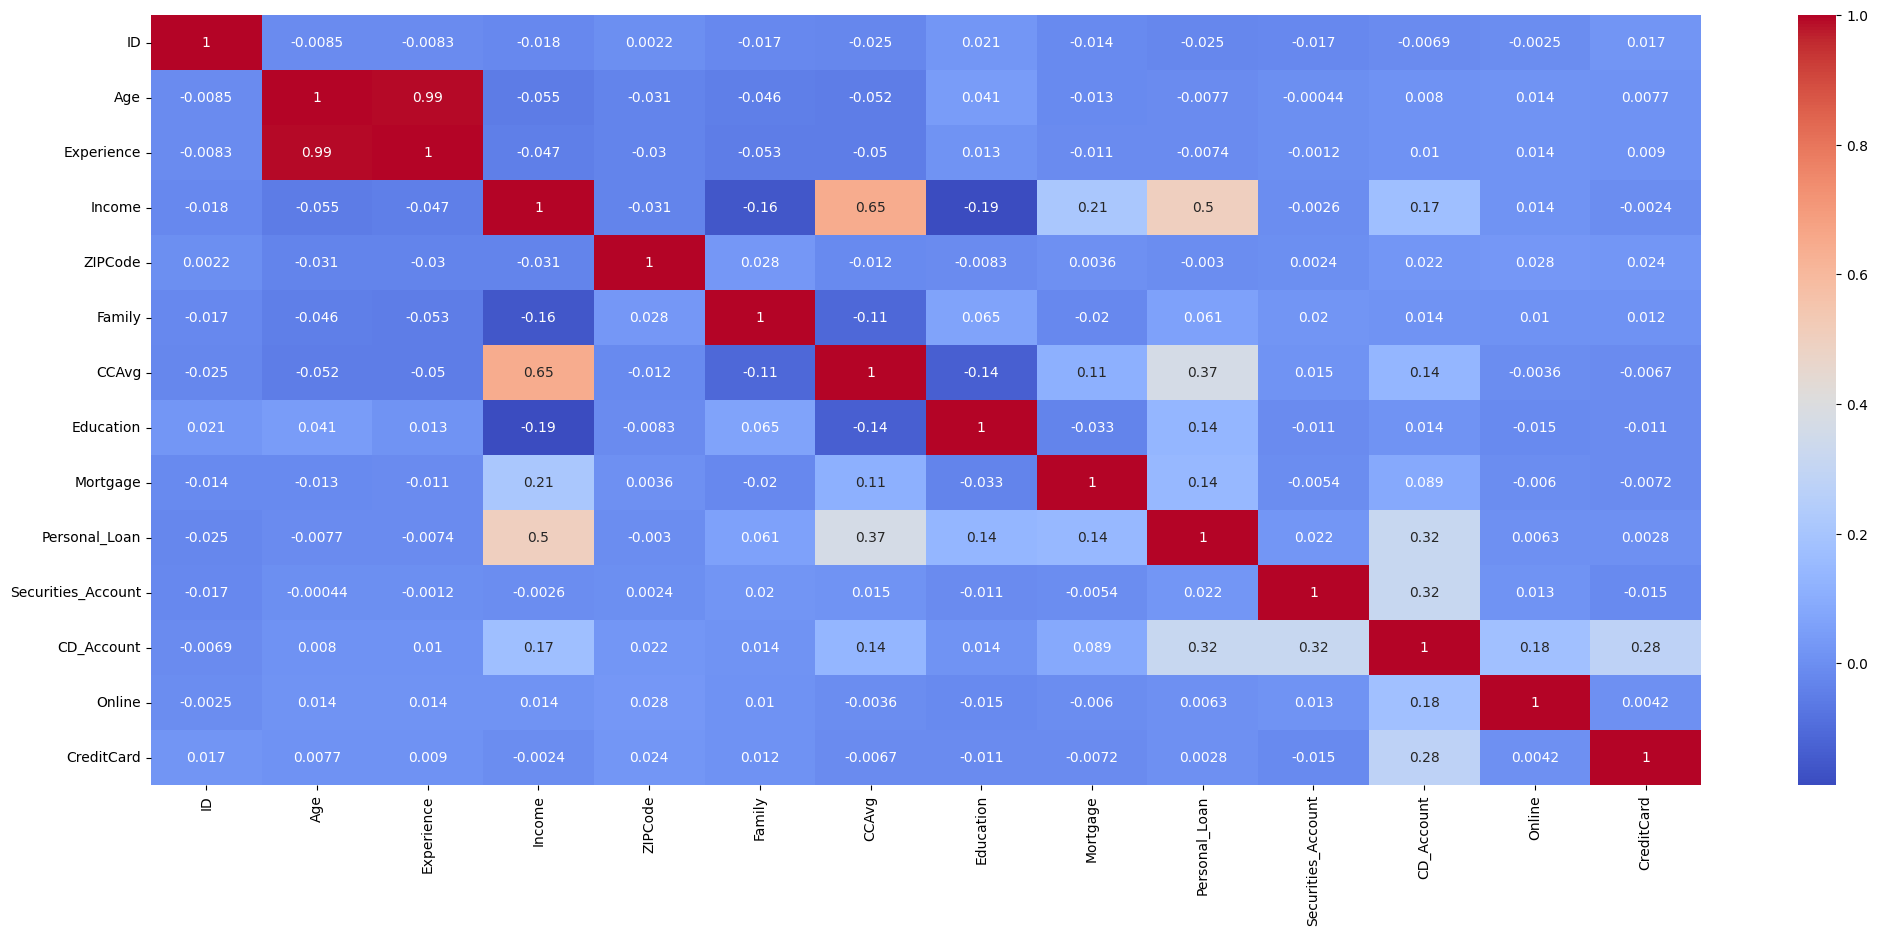

In [ ]:
plt.figure(figsize=(25, 10))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.show()

### Observations:
*   The personal_loan attribute is most correlated with income.
*   It shows that the more the income of the person the more likely the person is to take a personal loan for their financial activities.

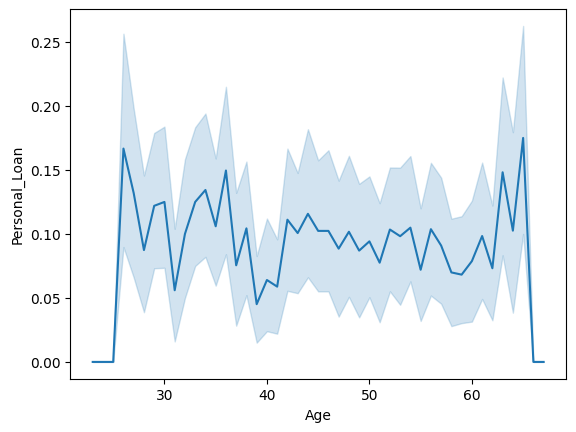

In [ ]:
sns.lineplot(data=data, x='Age', y='Personal_Loan')
plt.show()

### Observations:
*   There are two peaks in the lineplot which shows that there are two ages at which maximum number of personal loans are taken.
*   Most people might have taken loans because either they want to pursue higher education because they maybe crossing 20 or because they want to spend in healthcare because of old age.

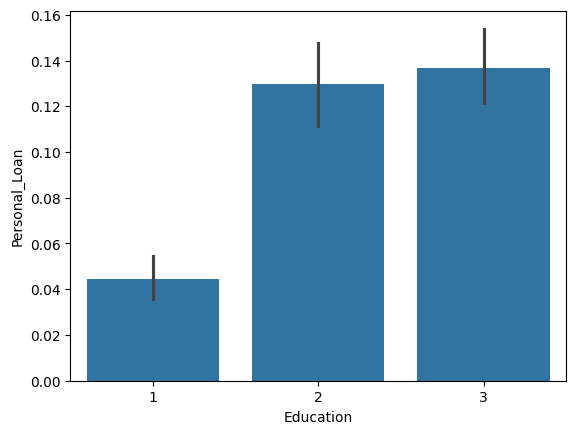

In [ ]:
sns.barplot(data=data, x='Education', y='Personal_Loan')
plt.show()

### Observations:
*   We can see that as the education level increases there is more likeliness to take a personal loan.
*   This shows that education can influence loan taking

## Data Preprocessing

* Missing value treatment
* Feature engineering (if needed)
* Outlier detection and treatment (if needed)
* Preparing data for modeling
* Any other preprocessing steps (if needed)

##### Outlier Detection and Treatment

In [ ]:
data['Experience'].unique()

array([ 1, 19, 15,  9,  8, 13, 27, 24, 10, 39,  5, 23, 32, 41, 30, 14, 18,
       21, 28, 31, 11, 16, 20, 35,  6, 25,  7, 12, 26, 37, 17,  2, 36, 29,
        3, 22, -1, 34,  0, 38, 40, 33,  4, -2, 42, -3, 43])

In [ ]:
data['Experience'] = data['Experience'].apply(lambda x: max(x, 0))

* We can see that there is outlier values showing negative years of experience. We convert that to 0 years of experience

In [ ]:
data['Mortgage'].unique()

array([  0, 155, 104, 134, 111, 260, 163, 159,  97, 122, 193, 198, 285,
       412, 153, 211, 207, 240, 455, 112, 336, 132, 118, 174, 126, 236,
       166, 136, 309, 103, 366, 101, 251, 276, 161, 149, 188, 116, 135,
       244, 164,  81, 315, 140,  95,  89,  90, 105, 100, 282, 209, 249,
        91,  98, 145, 150, 169, 280,  99,  78, 264, 113, 117, 325, 121,
       138,  77, 158, 109, 131, 391,  88, 129, 196, 617, 123, 167, 190,
       248,  82, 402, 360, 392, 185, 419, 270, 148, 466, 175, 147, 220,
       133, 182, 290, 125, 124, 224, 141, 119, 139, 115, 458, 172, 156,
       547, 470, 304, 221, 108, 179, 271, 378, 176,  76, 314,  87, 203,
       180, 230, 137, 152, 485, 300, 272, 144,  94, 208, 275,  83, 218,
       327, 322, 205, 227, 239,  85, 160, 364, 449,  75, 107,  92, 187,
       355, 106, 587, 214, 307, 263, 310, 127, 252, 170, 265, 177, 305,
       372,  79, 301, 232, 289, 212, 250,  84, 130, 303, 256, 259, 204,
       524, 157, 231, 287, 247, 333, 229, 357, 361, 294,  86, 32

In [ ]:
data['Income'].unique()

array([ 49,  34,  11, 100,  45,  29,  72,  22,  81, 180, 105, 114,  40,
       112, 130, 193,  21,  25,  63,  62,  43, 152,  83, 158,  48, 119,
        35,  41,  18,  50, 121,  71, 141,  80,  84,  60, 132, 104,  52,
       194,   8, 131, 190,  44, 139,  93, 188,  39, 125,  32,  20, 115,
        69,  85, 135,  12, 133,  19,  82, 109,  42,  78,  51, 113, 118,
        64, 161,  94,  15,  74,  30,  38,   9,  92,  61,  73,  70, 149,
        98, 128,  31,  58,  54, 124, 163,  24,  79, 134,  23,  13, 138,
       171, 168,  65,  10, 148, 159, 169, 144, 165,  59,  68,  91, 172,
        55, 155,  53,  89,  28,  75, 170, 120,  99, 111,  33, 129, 122,
       150, 195, 110, 101, 191, 140, 153, 173, 174,  90, 179, 145, 200,
       183, 182,  88, 160, 205, 164,  14, 175, 103, 108, 185, 204, 154,
       102, 192, 202, 162, 142,  95, 184, 181, 143, 123, 178, 198, 201,
       203, 189, 151, 199, 224, 218])

In [ ]:
data['Family'].unique()

array([4, 3, 1, 2])

In [ ]:
print(data['CCAvg'].unique())
print(data['Education'].unique())
print(data['Mortgage'].unique())
print(data['Personal_Loan'].unique())
print(data['Securities_Account'].unique())
print(data['CD_Account'].unique())
print(data['Online'].unique())
print(data['CreditCard'].unique())

[ 1.6   1.5   1.    2.7   0.4   0.3   0.6   8.9   2.4   0.1   3.8   2.5
  2.    4.7   8.1   0.5   0.9   1.2   0.7   3.9   0.2   2.2   3.3   1.8
  2.9   1.4   5.    2.3   1.1   5.7   4.5   2.1   8.    1.7   0.    2.8
  3.5   4.    2.6   1.3   5.6   5.2   3.    4.6   3.6   7.2   1.75  7.4
  2.67  7.5   6.5   7.8   7.9   4.1   1.9   4.3   6.8   5.1   3.1   0.8
  3.7   6.2   0.75  2.33  4.9   0.67  3.2   5.5   6.9   4.33  7.3   4.2
  4.4   6.1   6.33  6.6   5.3   3.4   7.    6.3   8.3   6.    1.67  8.6
  7.6   6.4  10.    5.9   5.4   8.8   1.33  9.    6.7   4.25  6.67  5.8
  4.8   3.25  5.67  8.5   4.75  4.67  3.67  8.2   3.33  5.33  9.3   2.75]
[1 2 3]
[  0 155 104 134 111 260 163 159  97 122 193 198 285 412 153 211 207 240
 455 112 336 132 118 174 126 236 166 136 309 103 366 101 251 276 161 149
 188 116 135 244 164  81 315 140  95  89  90 105 100 282 209 249  91  98
 145 150 169 280  99  78 264 113 117 325 121 138  77 158 109 131 391  88
 129 196 617 123 167 190 248  82 402 360 392 185 4

* All columns other than experience are all correct and no outlier values are present.
* Mortgage even be left as it is because decision trees can handle realistic outlier values and can be left as is.

##### Feature engineering

In [ ]:
from uszipcode import SearchEngine
import pandas as pd
import time

search = SearchEngine()
unique_zips = data['ZIPCode'].unique()

zip_data = {}
for zip_code in unique_zips:
    result = search.by_zipcode(zip_code)
    if result:
        zip_data[zip_code] = {
            "State": result.state,
            "City": result.major_city,
            "Population": result.population,
            "MedianIncome": result.median_household_income
        }
    else:
        zip_data[zip_code] = {
            "State": None,
            "City": None,
            "Population": None,
            "MedianIncome": None
        }

    time.sleep(0.05)

zip_enriched_df = pd.DataFrame.from_dict(zip_data, orient='index').reset_index()
zip_enriched_df.rename(columns={'index': 'ZIPCode'}, inplace=True)

data = pd.merge(data, zip_enriched_df, on='ZIPCode', how='left')
data

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard,State,City,Population,MedianIncome
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0,CA,Pasadena,32940.0,80936.0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0,CA,Los Angeles,NaN,NaN
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0,CA,Berkeley,NaN,NaN
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0,CA,San Francisco,79407.0,71625.0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1,CA,Northridge,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,29,3,40,92697,1,1.9,3,0,0,0,0,1,0,CA,Irvine,NaN,NaN
4996,4997,30,4,15,92037,4,0.4,1,85,0,0,0,1,0,CA,La Jolla,46781.0,99367.0
4997,4998,63,39,24,93023,2,0.3,3,0,0,0,0,0,0,CA,Ojai,20589.0,62133.0
4998,4999,65,40,49,90034,3,0.5,2,0,0,0,0,1,0,CA,Los Angeles,57964.0,56946.0


In [ ]:
data['City'].unique()

array(['Pasadena', 'Los Angeles', 'Berkeley', 'San Francisco',
       'Northridge', 'San Diego', 'Claremont', 'Monterey', 'Ojai',
       'Redondo Beach', 'Santa Barbara', 'Belvedere Tiburon', 'Glendora',
       'Santa Clara', 'Capitola', 'Stanford', 'Studio City', 'Daly City',
       'Newbury Park', 'Arcata', 'Santa Cruz', 'Fremont', 'Richmond',
       'Mountain View', 'Huntington Beach', 'Sacramento', 'San Clemente',
       'Davis', 'Redwood City', 'Cupertino', 'Santa Clarita', 'Roseville',
       'Redlands', 'La Jolla', 'Brisbane', 'El Segundo', 'Los Altos',
       'Santa Monica', 'San Luis Obispo', 'Pleasant Hill',
       'Thousand Oaks', 'Rancho Cordova', 'San Jose', 'Reseda', 'Salinas',
       'Cardiff By The Sea', 'Oakland', 'San Rafael', 'Banning',
       'Bakersfield', 'Riverside', 'Rancho Cucamonga', 'Alameda',
       'Palo Alto', 'Livermore', 'Irvine', 'South San Francisco',
       'Emeryville', 'Ridgecrest', None, 'Hayward', 'San Gabriel',
       'Santa Ana', 'Loma Linda', '

##### Missing value treatment

In [ ]:
data.fillna(data.median(numeric_only=True), inplace=True)
data

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard,State,City,Population,MedianIncome
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0,CA,Pasadena,32940.0,80936.0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0,CA,Los Angeles,34204.0,75599.0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0,CA,Berkeley,34204.0,75599.0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0,CA,San Francisco,79407.0,71625.0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1,CA,Northridge,34204.0,75599.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,29,3,40,92697,1,1.9,3,0,0,0,0,1,0,CA,Irvine,34204.0,75599.0
4996,4997,30,4,15,92037,4,0.4,1,85,0,0,0,1,0,CA,La Jolla,46781.0,99367.0
4997,4998,63,39,24,93023,2,0.3,3,0,0,0,0,0,0,CA,Ojai,20589.0,62133.0
4998,4999,65,40,49,90034,3,0.5,2,0,0,0,0,1,0,CA,Los Angeles,57964.0,56946.0


##### Other preprocessing steps:
* We convert encode the label for the city column to enable the fitting of data in the decision tree classifier.

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = ['City']

for col in categorical_cols:
    data[col] = le.fit_transform(data[col].astype(str))

In [ ]:
data['State'].unique()

array(['CA', None], dtype=object)

##### Preparing data for modeling

In [ ]:
X = data.drop(['Personal_Loan', 'State', 'ZIPCode'], axis=1)
y = data['Personal_Loan']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Model Building

In [ ]:
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

### Model Evaluation Criterion

* We find the different parameters(Impurity measures) such as gini impurity and also the entropy.
* The metrics we will use are accuracy, recall, precision, f1 scores.


### Model Building

In [ ]:
def model_performance_classification(model, predictors, target):
  pred = model.predict(predictors)

  accuracy = accuracy_score(target, pred)
  f1 = f1_score(target, pred)
  recall = recall_score(target, pred)
  precision = precision_score(target, pred)

  df_perf = pd.DataFrame({
      'Accuracy': accuracy,
      'F1 Score': f1,
      'Recall': recall,
      'Precision': precision
  }, index=[0])

  return df_perf

In [ ]:
def plot_confusion_matrix(model, predictors, target):
  y_pred = model.predict(predictors)

  cm = confusion_matrix(target, y_pred)

  labels = np.asarray([['{0:.0f}'.format(item) + '\n{0:.2%}'.format(item/cm.flatten().sum())] for item in cm.flatten()]).reshape(2, 2)

  plt.figure(figsize=(6, 4))

  sns.heatmap(data=cm, annot=labels, fmt='')
  plt.title('Confusion Matrix')
  plt.xlabel('Predicted')
  plt.ylabel('Actual')
  plt.show()

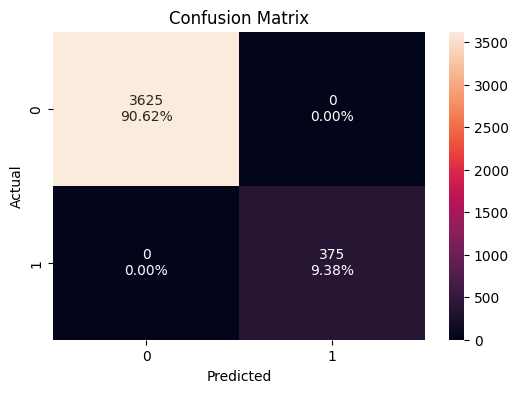

In [ ]:
plot_confusion_matrix(model, X_train, y_train)

In [ ]:
model1_train_perf = model_performance_classification(model, X_train, y_train)
model1_train_perf

,Accuracy,F1 Score,Recall,Precision
0,1.0,1.0,1.0,1.0


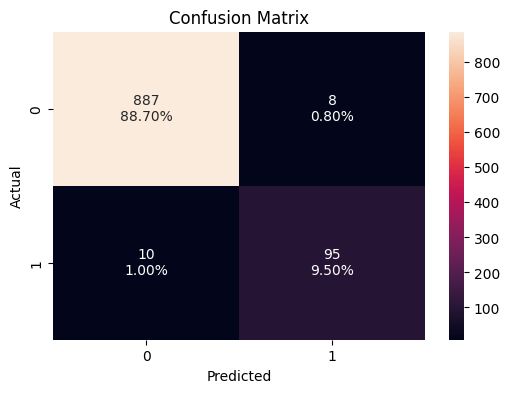

In [ ]:
plot_confusion_matrix(model, X_test, y_test)

In [ ]:
model1_test_perf = model_performance_classification(model, X_test, y_test)
model1_test_perf

,Accuracy,F1 Score,Recall,Precision
0,0.982,0.913462,0.904762,0.92233


### Visualizing the tree

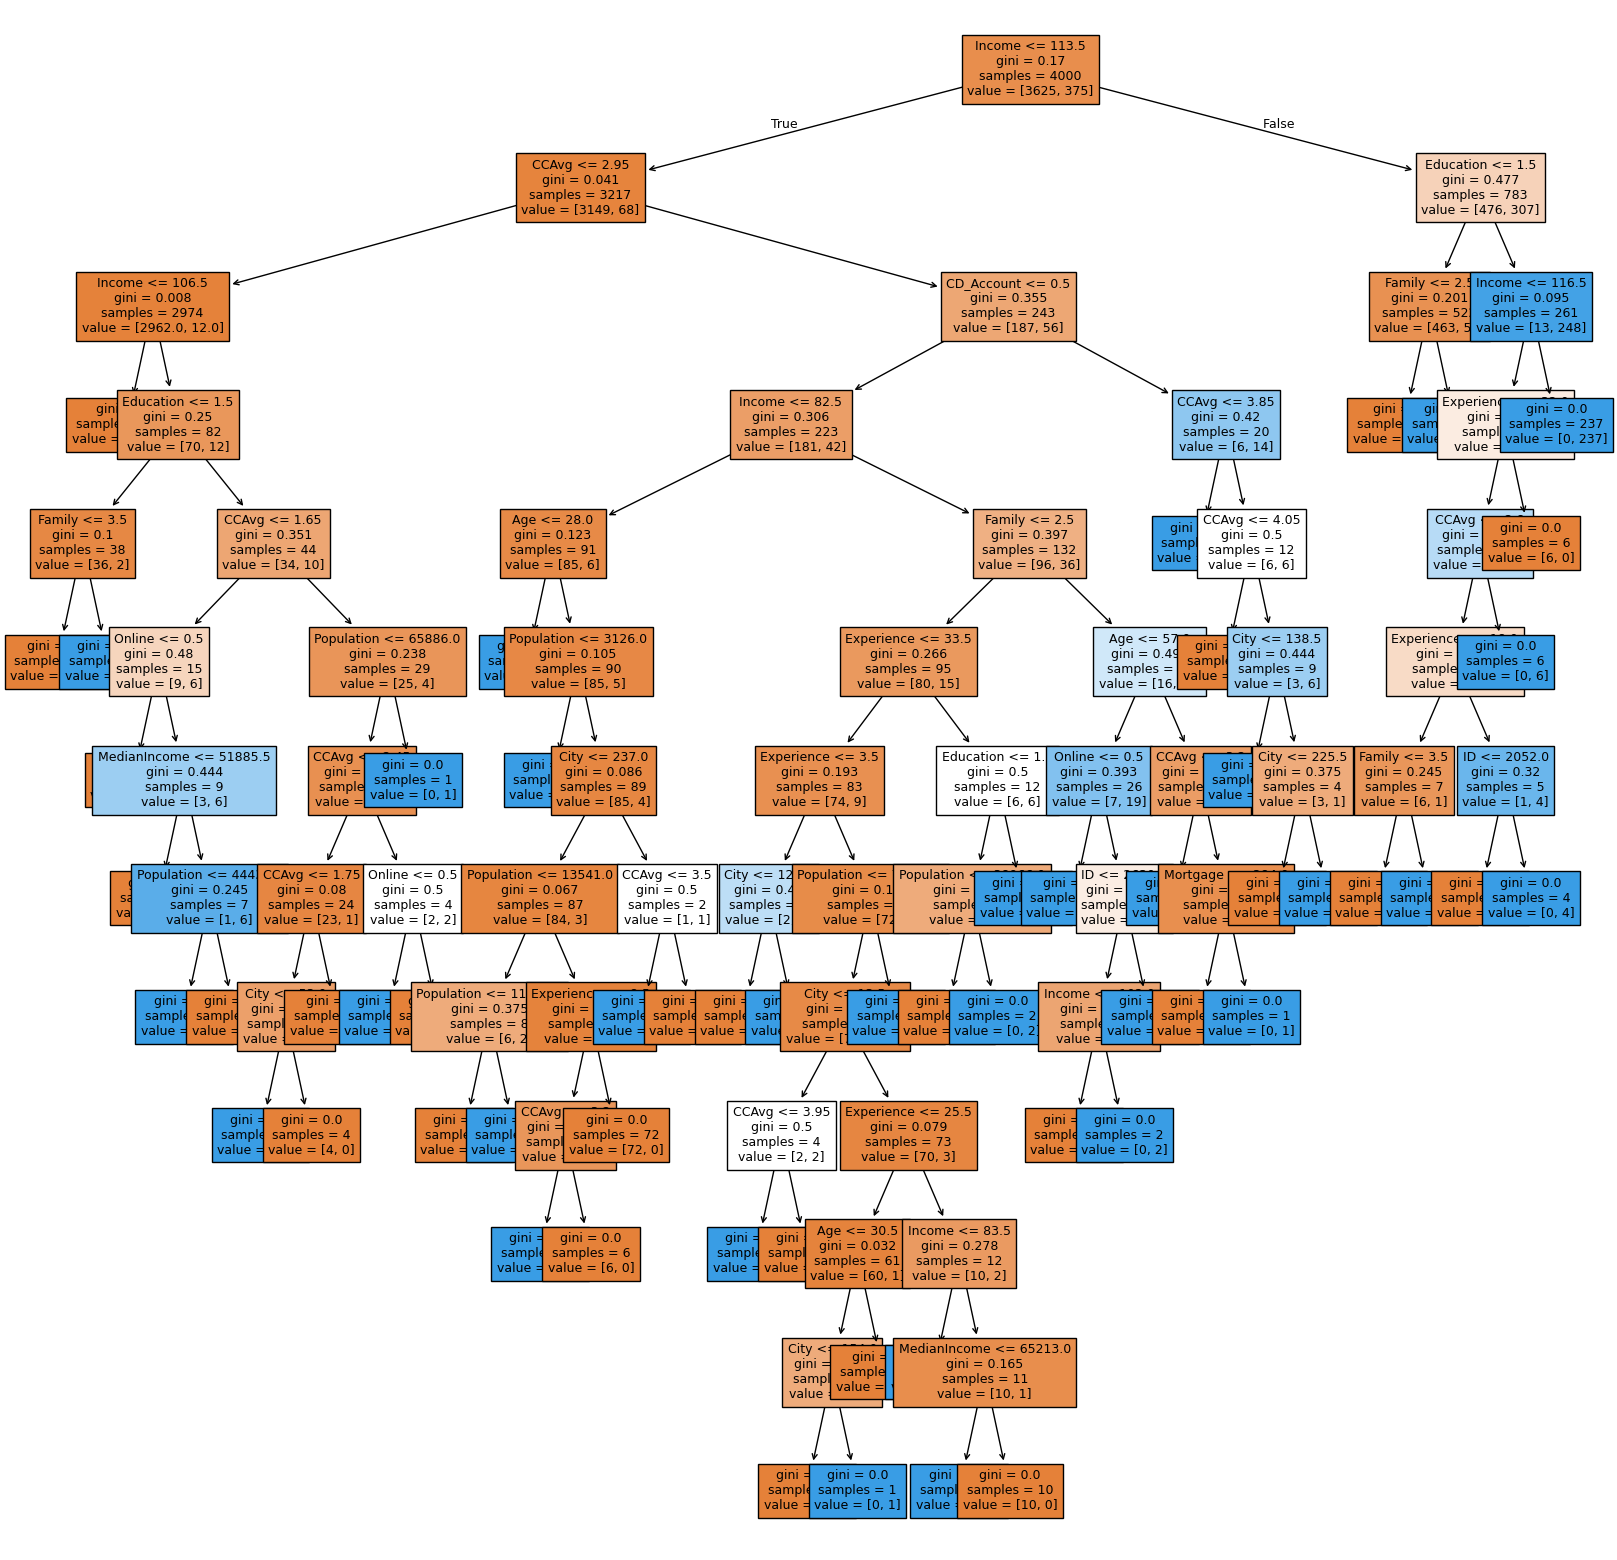

In [ ]:
feature_names = list(X_train.columns)

plt.figure(figsize=(20, 20))

nodes = tree.plot_tree(model, feature_names=feature_names, filled=True, fontsize=9, node_ids=False, class_names=None,)

for node in nodes:
  arrow = node.arrow_patch
  if arrow is not None:
    arrow.set_edgecolor('black')
    arrow.set_linewidth(1)

plt.show()

### Observations:
* This is an overfitted decision tree as the leaf nodes are having sample size of 1.
* But because this data is clean the decision making has been very effective(98.5% accuracy)

In [ ]:
print(tree.export_text(model, feature_names=feature_names, show_weights=True))

|--- Income <= 113.50
|   |--- CCAvg <= 2.95
|   |   |--- Income <= 106.50
|   |   |   |--- weights: [2892.00, 0.00] class: 0
|   |   |--- Income >  106.50
|   |   |   |--- Education <= 1.50
|   |   |   |   |--- Family <= 3.50
|   |   |   |   |   |--- weights: [36.00, 0.00] class: 0
|   |   |   |   |--- Family >  3.50
|   |   |   |   |   |--- weights: [0.00, 2.00] class: 1
|   |   |   |--- Education >  1.50
|   |   |   |   |--- CCAvg <= 1.65
|   |   |   |   |   |--- Online <= 0.50
|   |   |   |   |   |   |--- weights: [6.00, 0.00] class: 0
|   |   |   |   |   |--- Online >  0.50
|   |   |   |   |   |   |--- MedianIncome <= 51885.50
|   |   |   |   |   |   |   |--- weights: [2.00, 0.00] class: 0
|   |   |   |   |   |   |--- MedianIncome >  51885.50
|   |   |   |   |   |   |   |--- Population <= 44433.50
|   |   |   |   |   |   |   |   |--- weights: [0.00, 6.00] class: 1
|   |   |   |   |   |   |   |--- Population >  44433.50
|   |   |   |   |   |   |   |   |--- weights: [1.00, 0.00] cla

## Model Performance Improvement

## Model Performance Comparison and Final Model Selection

### Decision Tree (Pre-pruning)

In [ ]:
max_depth_values = np.arange(2, 11, 2)
max_leaf_nodes = np.arange(10, 51, 10)
min_samples_split = np.arange(10, 51, 10)

best_estimator = None
best_score_diff = float('inf')

for max_depth in max_depth_values:
  for max_leaf in max_leaf_nodes:
    for min_samples in min_samples_split:
      estimator = DecisionTreeClassifier(max_depth=max_depth, max_leaf_nodes=max_leaf, min_samples_split=min_samples, random_state=42)

      estimator.fit(X_train, y_train)

      y_train_pred = estimator.predict(X_train)
      y_test_pred = estimator.predict(X_test)

      train_f1_score = f1_score(y_train, y_train_pred)
      test_f1_score = f1_score(y_test, y_test_pred)

      score_diff = abs(train_f1_score - test_f1_score)

      if score_diff < best_score_diff:
        best_score_diff = score_diff
        best_estimator = estimator

In [ ]:
model2 = best_estimator

model2.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=np.int64(8), max_leaf_nodes=np.int64(20),
                       min_samples_split=np.int64(30), random_state=42)

### Model Evaluation

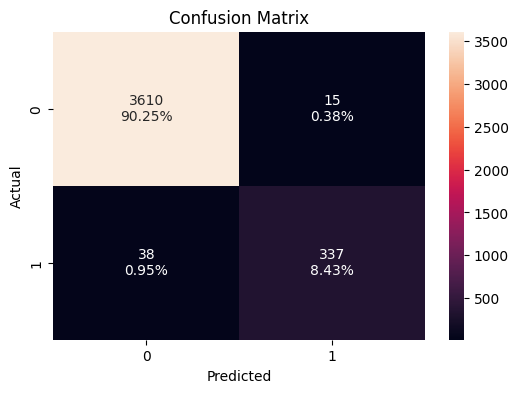

In [ ]:
plot_confusion_matrix(model2, X_train, y_train)

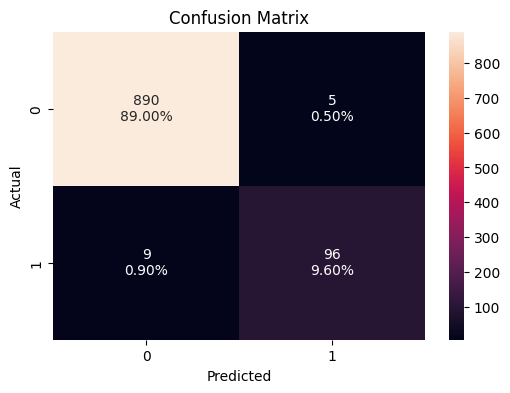

In [ ]:
plot_confusion_matrix(model2, X_test, y_test)

In [ ]:
model2_train_perf = model_performance_classification(model2, X_train, y_train)
model2_train_perf

,Accuracy,F1 Score,Recall,Precision
0,0.98675,0.927098,0.898667,0.957386


In [ ]:
model2_test_perf = model_performance_classification(model2, X_test, y_test)
model2_test_perf

,Accuracy,F1 Score,Recall,Precision
0,0.986,0.932039,0.914286,0.950495


### Decision tree visualization

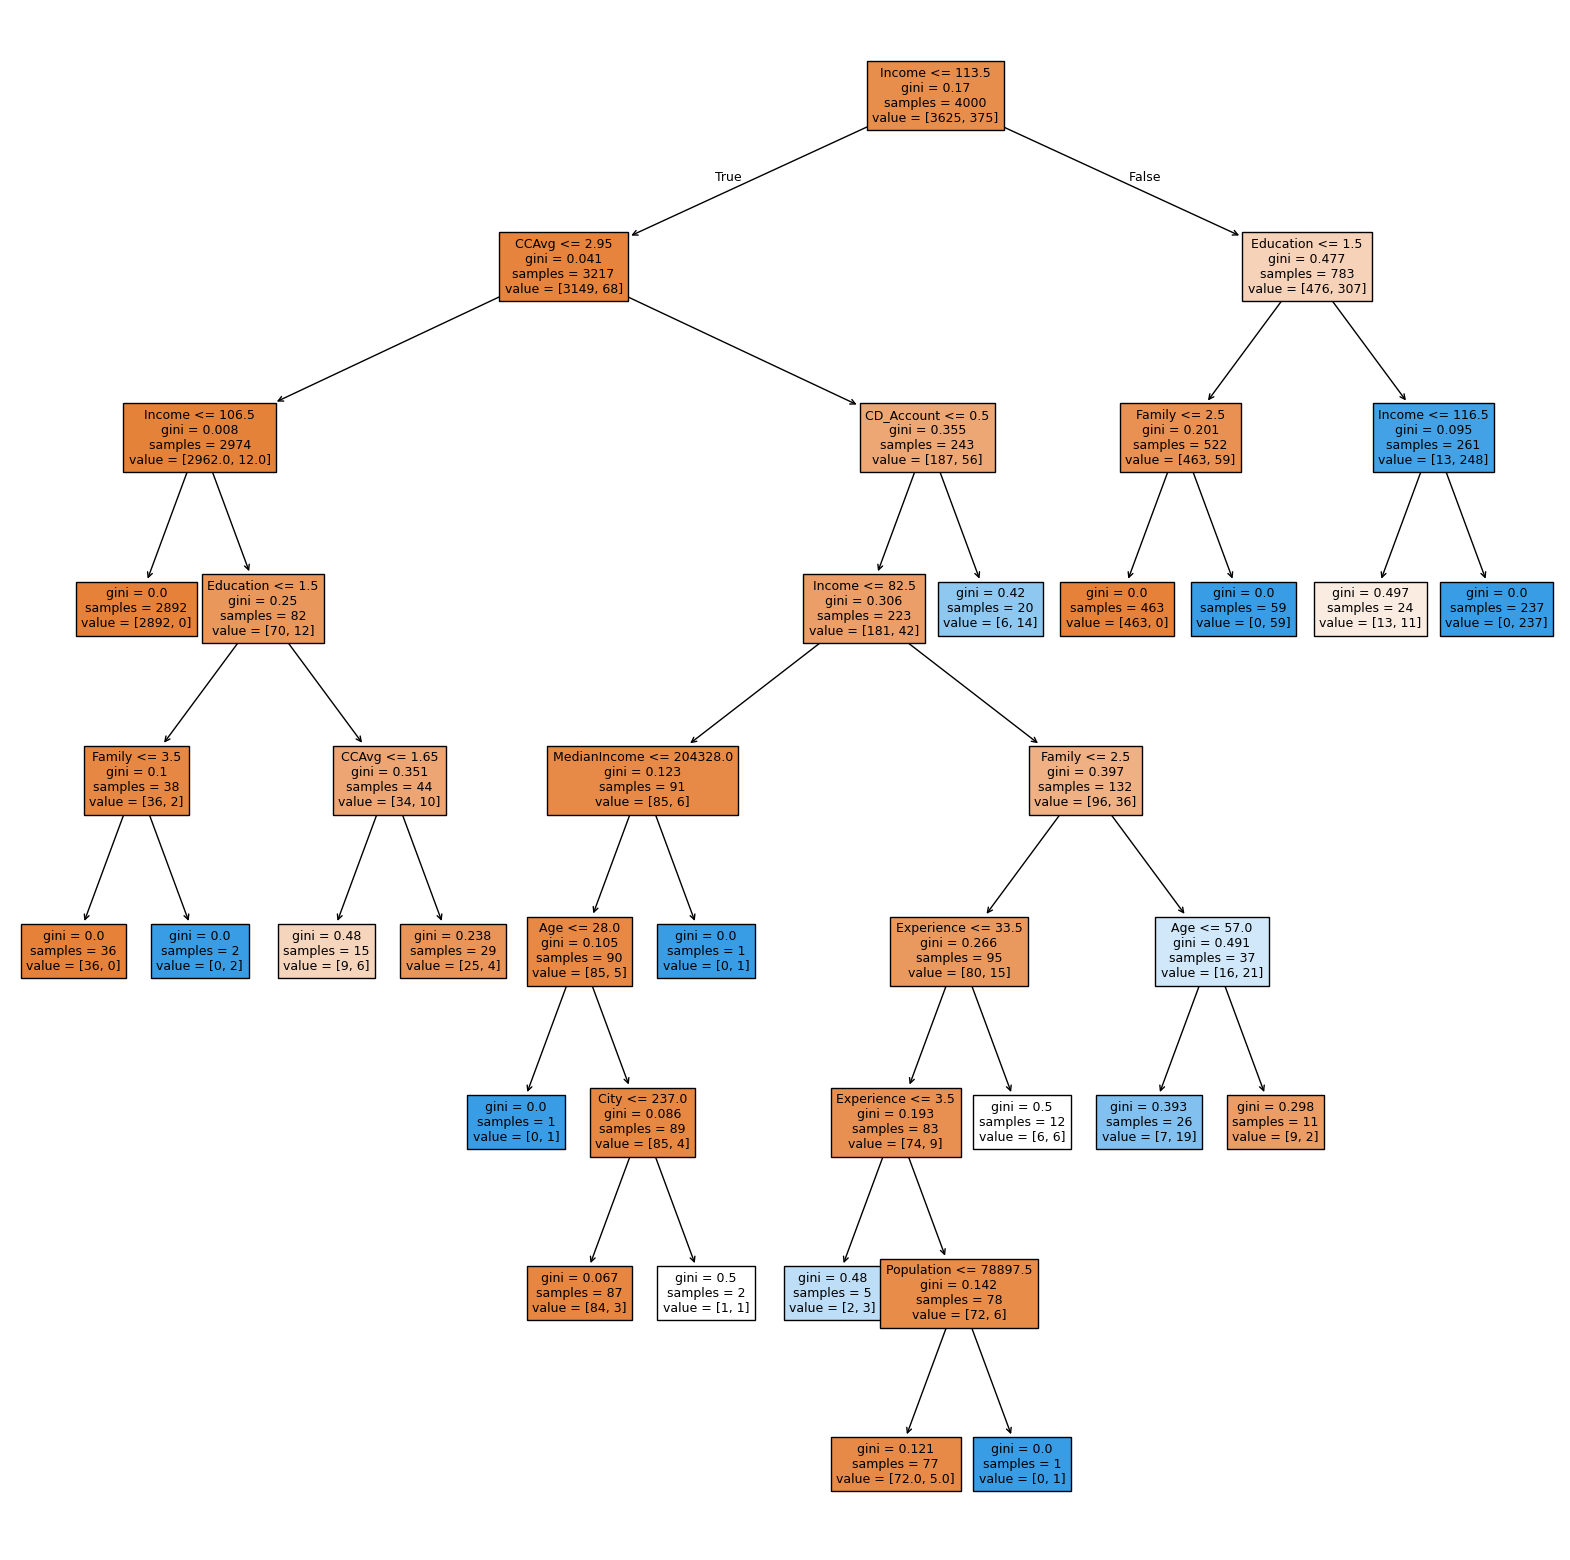

In [ ]:
plt.figure(figsize=(20, 20))

tree2 = tree.plot_tree(model2, feature_names=feature_names, filled=True, fontsize=9, node_ids=False, class_names=None,)

for node in tree2:
  arrow = node.arrow_patch
  if arrow is not None:
    arrow.set_edgecolor('black')
    arrow.set_linewidth(1)

plt.show()

In [ ]:
print(tree.export_text(model2, feature_names=feature_names, show_weights=True))

|--- Income <= 113.50
|   |--- CCAvg <= 2.95
|   |   |--- Income <= 106.50
|   |   |   |--- weights: [2892.00, 0.00] class: 0
|   |   |--- Income >  106.50
|   |   |   |--- Education <= 1.50
|   |   |   |   |--- Family <= 3.50
|   |   |   |   |   |--- weights: [36.00, 0.00] class: 0
|   |   |   |   |--- Family >  3.50
|   |   |   |   |   |--- weights: [0.00, 2.00] class: 1
|   |   |   |--- Education >  1.50
|   |   |   |   |--- CCAvg <= 1.65
|   |   |   |   |   |--- weights: [9.00, 6.00] class: 0
|   |   |   |   |--- CCAvg >  1.65
|   |   |   |   |   |--- weights: [25.00, 4.00] class: 0
|   |--- CCAvg >  2.95
|   |   |--- CD_Account <= 0.50
|   |   |   |--- Income <= 82.50
|   |   |   |   |--- MedianIncome <= 204328.00
|   |   |   |   |   |--- Age <= 28.00
|   |   |   |   |   |   |--- weights: [0.00, 1.00] class: 1
|   |   |   |   |   |--- Age >  28.00
|   |   |   |   |   |   |--- City <= 237.00
|   |   |   |   |   |   |   |--- weights: [84.00, 3.00] class: 0
|   |   |   |   |   |   |-

### Decision Tree (Post-pruning)

In [ ]:
model3 = DecisionTreeClassifier(random_state=42)

path = model3.cost_complexity_pruning_path(X_train, y_train)

ccp_alphas, impurities = abs(path.ccp_alphas), path.impurities

In [ ]:
pd.DataFrame(path)

,ccp_alphas,impurities
0,0.000000,0.000000
1,0.000240,0.000479
2,0.000246,0.000971
3,0.000247,0.001465
4,0.000250,0.001715
5,0.000316,0.002661
6,0.000375,0.003036
7,0.000389,0.004203
8,0.000400,0.004603
9,0.000409,0.005421


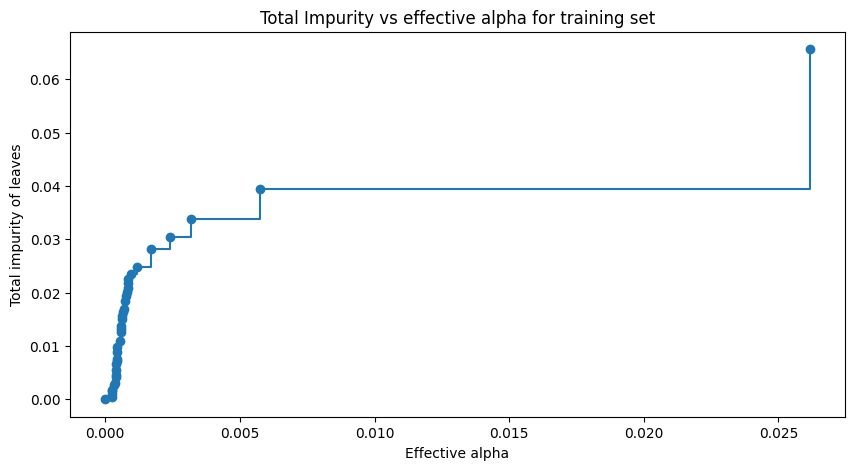

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(ccp_alphas[:-1], impurities[:-1], marker='o', drawstyle='steps-post')
ax.set_xlabel('Effective alpha')
ax.set_ylabel('Total impurity of leaves')
ax.set_title('Total Impurity vs effective alpha for training set')

plt.show()

In [ ]:
models = []

for ccp_alpha in ccp_alphas:
  m = DecisionTreeClassifier(random_state=42, ccp_alpha=ccp_alpha)

  m.fit(X_train, y_train)

  models.append(m)

print('Number of nodes in the last tree is {} with ccp_alpha: {}'.format(models[-1].tree_.node_count, ccp_alphas[-1]))

Number of nodes in the last tree is 1 with ccp_alpha: 0.05214930148943829


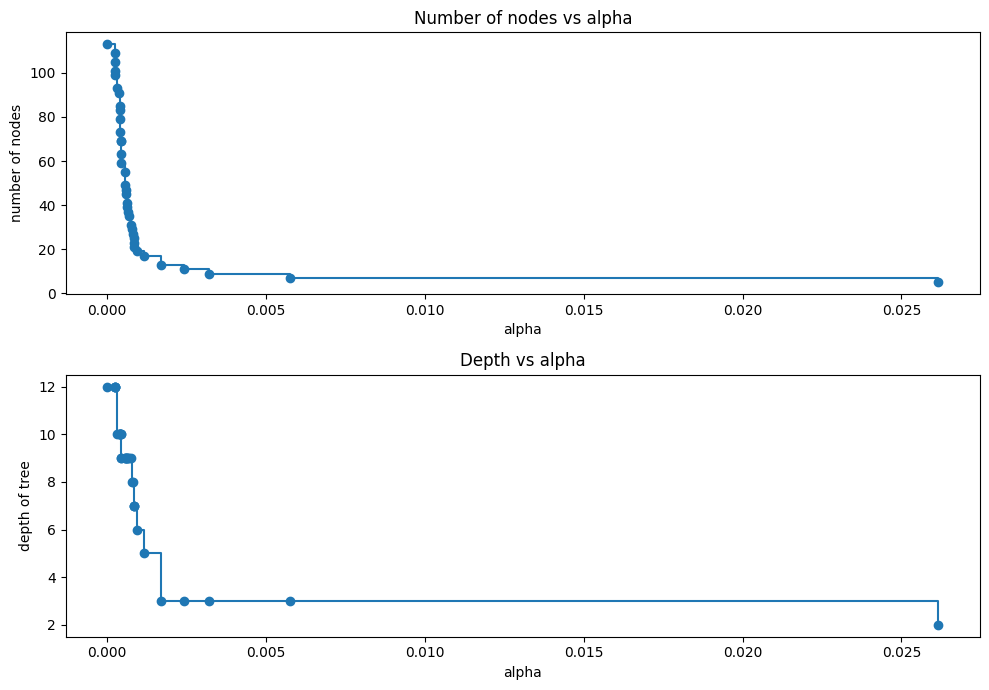

In [ ]:
models = models[:-1]
ccp_alphas = ccp_alphas[:-1]

node_counts = [model.tree_.node_count for model in models]
depth = [model.tree_.max_depth for model in models]

fig, ax = plt.subplots(2, 1, figsize=(10, 7))
ax[0].plot(ccp_alphas, node_counts, marker='o', drawstyle='steps-post')
ax[0].set_xlabel('alpha')
ax[0].set_ylabel('number of nodes')
ax[0].set_title('Number of nodes vs alpha')

ax[1].plot(ccp_alphas, depth, marker='o', drawstyle='steps-post')
ax[1].set_xlabel('alpha')
ax[1].set_ylabel('depth of tree')
ax[1].set_title('Depth vs alpha')

fig.tight_layout()

In [ ]:
train_f1_scores = []

for model in models:
  y_train_pred = model.predict(X_train)
  train_f1_scores.append(f1_score(y_train, y_train_pred))

In [ ]:
test_f1_scores = []

for model in models:
  y_test_pred = model.predict(X_test)
  test_f1_scores.append(f1_score(y_test, y_test_pred))

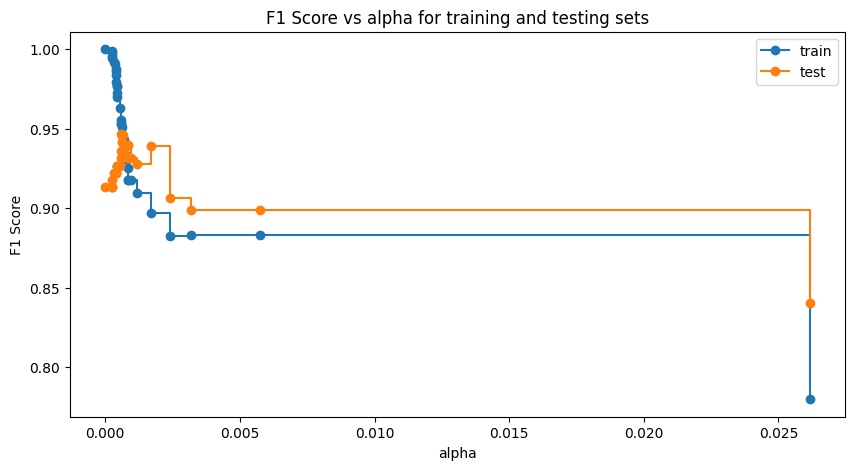

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(ccp_alphas, train_f1_scores, marker='o', label='train', drawstyle='steps-post')
ax.plot(ccp_alphas, test_f1_scores, marker='o', label='test', drawstyle='steps-post')
ax.set_xlabel('alpha')
ax.set_ylabel('F1 Score')
ax.set_title('F1 Score vs alpha for training and testing sets')
ax.legend()

plt.show()

In [ ]:
# Choosing the best model
model3 = models[np.argmax(test_f1_scores)]

print(model3)

DecisionTreeClassifier(ccp_alpha=np.float64(0.0006000000000000003),
                       random_state=42)


In [ ]:
model3_train_perf = model_performance_classification(model3, X_train, y_train)
model3_train_perf

,Accuracy,F1 Score,Recall,Precision
0,0.9915,0.953678,0.933333,0.97493


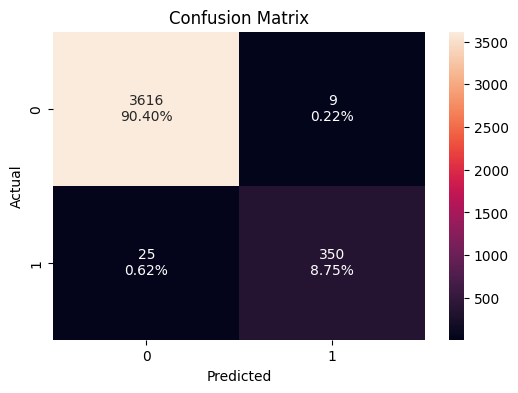

In [ ]:
plot_confusion_matrix(model3, X_train, y_train)

In [ ]:
model3_test_perf = model_performance_classification(model3, X_test, y_test)
model3_test_perf

,Accuracy,F1 Score,Recall,Precision
0,0.989,0.94686,0.933333,0.960784


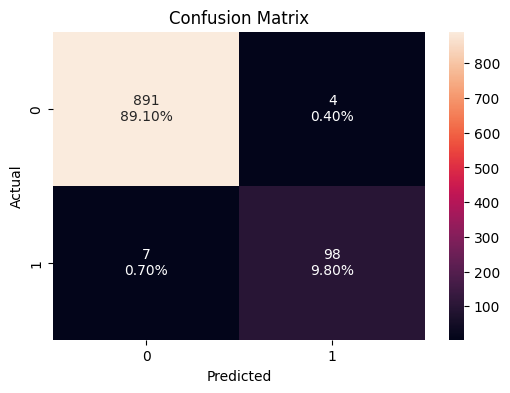

In [ ]:
plot_confusion_matrix(model3, X_test, y_test)

### Visualizing the Decision Tree

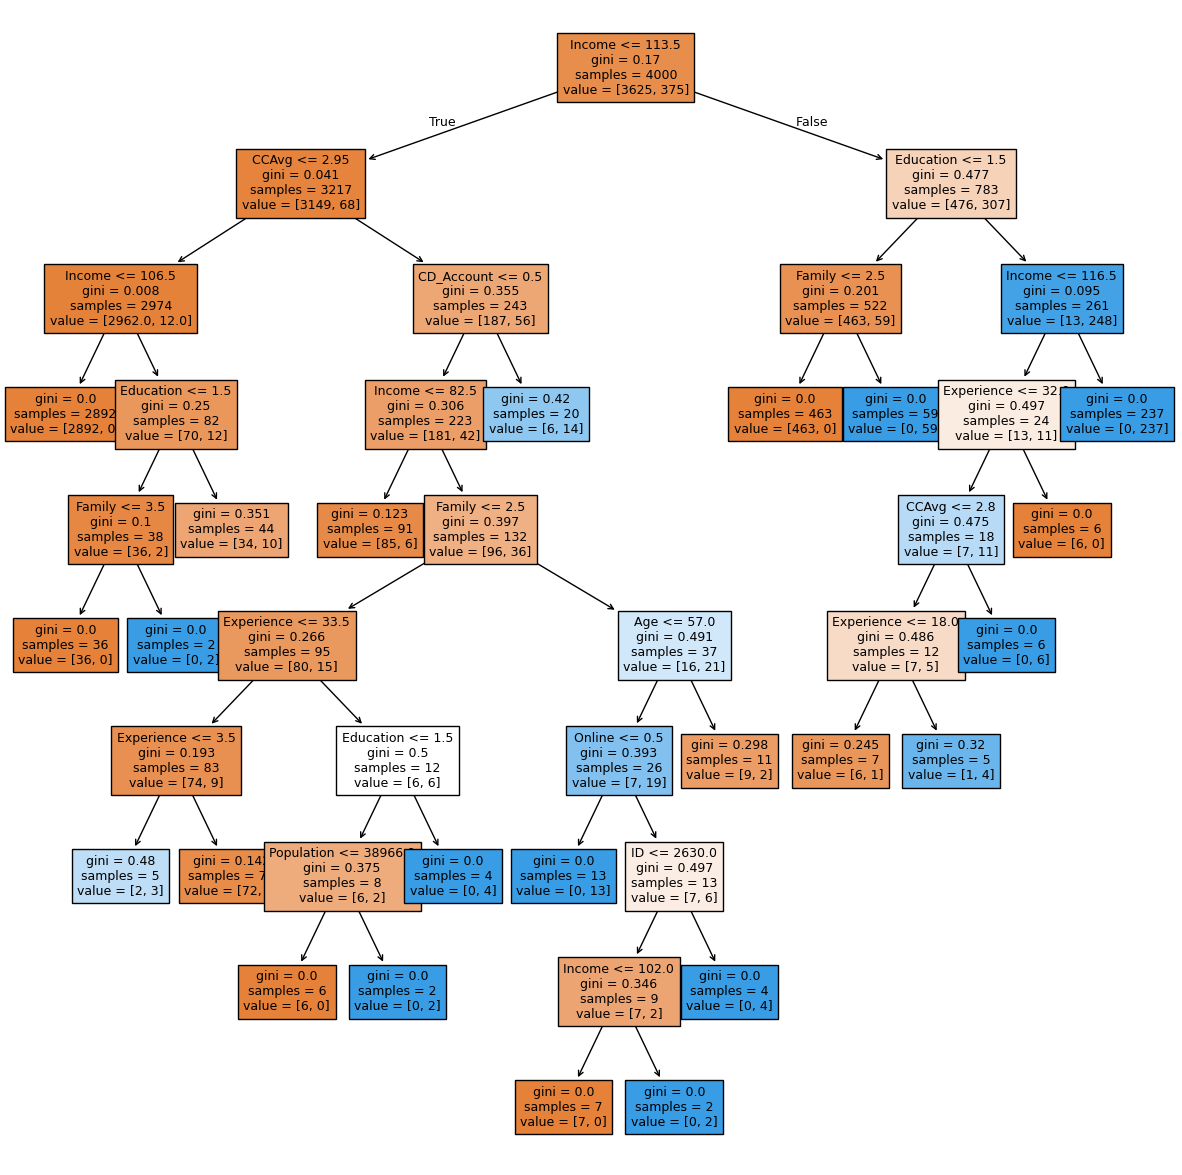

In [ ]:
feature_names = list(X_train.columns)

plt.figure(figsize=(15, 15))

nodes = tree.plot_tree(model3, feature_names=feature_names, filled=True, fontsize=9, node_ids=False, class_names=None)

for node in nodes:
  arrow = node.arrow_patch
  if arrow is not None:
    arrow.set_edgecolor('black')
    arrow.set_linewidth(1)

plt.show()

In [ ]:
print(tree.export_text(model3, feature_names=feature_names, show_weights=True))

|--- Income <= 113.50
|   |--- CCAvg <= 2.95
|   |   |--- Income <= 106.50
|   |   |   |--- weights: [2892.00, 0.00] class: 0
|   |   |--- Income >  106.50
|   |   |   |--- Education <= 1.50
|   |   |   |   |--- Family <= 3.50
|   |   |   |   |   |--- weights: [36.00, 0.00] class: 0
|   |   |   |   |--- Family >  3.50
|   |   |   |   |   |--- weights: [0.00, 2.00] class: 1
|   |   |   |--- Education >  1.50
|   |   |   |   |--- weights: [34.00, 10.00] class: 0
|   |--- CCAvg >  2.95
|   |   |--- CD_Account <= 0.50
|   |   |   |--- Income <= 82.50
|   |   |   |   |--- weights: [85.00, 6.00] class: 0
|   |   |   |--- Income >  82.50
|   |   |   |   |--- Family <= 2.50
|   |   |   |   |   |--- Experience <= 33.50
|   |   |   |   |   |   |--- Experience <= 3.50
|   |   |   |   |   |   |   |--- weights: [2.00, 3.00] class: 1
|   |   |   |   |   |   |--- Experience >  3.50
|   |   |   |   |   |   |   |--- weights: [72.00, 6.00] class: 0
|   |   |   |   |   |--- Experience >  33.50
|   |   | 

In [ ]:
models_train_df = pd.concat([model1_train_perf.T, model2_train_perf.T, model3_train_perf.T], axis=1)

models_train_df.columns = ['Decision Tree (default)', 'Decision Tree (Pre-pruning)', 'Decision Tree (Post-pruning)']

models_test_df = pd.concat([model1_test_perf.T, model2_test_perf.T, model3_test_perf.T], axis=1)

print("Training performance comparison: ")
models_train_df

Training performance comparison: 


,Decision Tree (default),Decision Tree (Pre-pruning),Decision Tree (Post-pruning)
Accuracy,1.0,0.986750,0.991500
F1 Score,1.0,0.927098,0.953678
Recall,1.0,0.898667,0.933333
Precision,1.0,0.957386,0.974930


In [ ]:
models_test_df = pd.concat([model1_test_perf.T, model2_test_perf.T, model3_test_perf.T], axis=1)

models_test_df.columns = ['Decision Tree (default)', 'Decision Tree (Pre-pruning)', 'Decision Tree (Post-pruning)']

print("Testing performance comparison: ")
models_test_df

Testing performance comparison: 


,Decision Tree (default),Decision Tree (Pre-pruning),Decision Tree (Post-pruning)
Accuracy,0.982000,0.986000,0.989000
F1 Score,0.913462,0.932039,0.946860
Recall,0.904762,0.914286,0.933333
Precision,0.922330,0.950495,0.960784


#### Observations:
* All parameters are showing a proper gradation in performances.

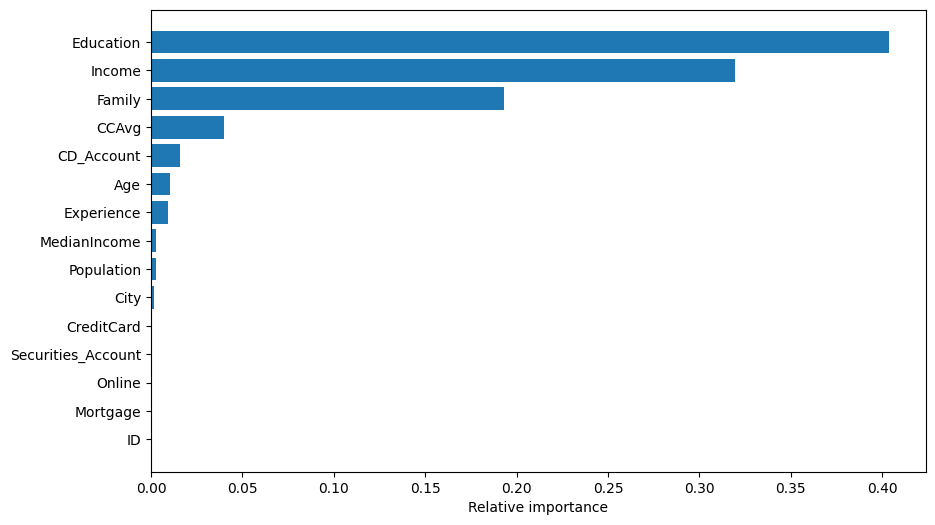

In [ ]:
importances = model2.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(10, 6))
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative importance')
plt.show()

#### Observations:
* From the feature importances we can see that education is a high contributing factor to customers applying for loans.
* During the EDA process as the level of education increased so did the number of people applying for loans increase.

### Predicting on a single data point

In [ ]:
%%time
applicant_details = X_test.iloc[:1, :]

y_pred = model2.predict(applicant_details)

print(y_pred)

[0]
CPU times: user 4.95 ms, sys: 0 ns, total: 4.95 ms
Wall time: 9.65 ms


In [ ]:
approval_likelihood = model2.predict_proba(applicant_details)

print(approval_likelihood[0, 1])

0.0


#### Observation
As there is not much difference in performance metrics between the 3 models we see that for a single applicant a very clear likelihood is shown by the model that the applicant should be rejected.

#### Choosing the best model
* The post-pruned decision tree is the best performing model and that is the most appropriate model.

## Actionable Insights and Business Recommendations


* What recommedations would you suggest to the bank?
* We can also derive the probability for the likelihood of approval.
* The accuracy of the models are above 90% even in the case of the default overfitted model. So not much manual screening needs to be done.
* Families with more mature members and high income should be preferred to be given loans as they show stability and can pay back the loan.
* Customers in selected cities can be preferred.
* Customers wanting a loan for education and also for health related issues can be considered and given higher priority but also looking at their income.
* This will reduce the overall screening time drastically for customers that usually wanting to go for higher education and are also in a high income bracket.

___